### Bradley-Terry-Luce Preference Modeling

The Bradley-Terry-Luce model estimates latent scores from paired comparisons. This notebook builds a preference-modeling example, fits comparison data, and uses the resulting scores to rank alternatives from noisy head-to-head choices.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import random
from math import log, exp
import statsmodels.api as sm

/usr/local/lib/python3.5/dist-packages/statsmodels/compat/pandas.py:56: FutureWarning: The pandas.core.datetools module is deprecated and will be removed in a future version. Please use the pandas.tseries module instead.
  from pandas.core import datetools


In [2]:
superheros = '''Batman
Spider-Man
Wolverine
Superman
Flash
Iron Man
Captain America
Hulk
Thor
Wonder Woman
Deadpool
Rogue
Daredevil
Green Lantern
Doctor Strange
Professor X
Black Panther
Nightwing
Storm
Magneto
Nightcrawler
Gambit
Green Arrow
Punisher
Jean Grey
Silver Surfer
Colossus
Beast
Aquaman
Martian Manhunter
Robin
Captain Marvel
Human Torch
Venom
Star-Lord
Hawkeye
Rorschach
Catwoman
Iceman
Black Widow
Groot
Scarlet Witch
Supergirl
Spawn
Hellboy
Batgirl
Cable
Mystique
Vision
Ant-Man
Phoenix
Shazam
Blade
Rocket Raccoon
Black Canary
Wally West
Psylocke
Ghost Rider
Quicksilver
Cyborg
Emma Frost
Invisible Woman
She-Hulk
John Constantine
Raven
Nick Fury
Zatanna
Iron Fist
Ms. Marvel (Carol Danvers)
War Machine
Shadowcat
Bucky Barnes
Moon Knight
Black Widow (Claire Voyant)
Archangel
John Stewart
Nova (Richard Rider)
Doctor Manhattan
Starfire
Captain Marvel
Hawkgirl
Gamora
Havok
X-23
Mister Fantastic
Oracle
Falcon
Ultimate Spider-Man
Hawkman
Odin
Red Robin
Ant-Man (Henry Pym)
Wasp
Elektra
Drax the Destroyer
Doctor Fate
Beast Boy
Domino
Jason Todd
Jubilee'''

In [42]:
created_by = '''Bill Finger, Bob Kane, Bruce Timm
Stan Lee, Steve Ditko
Len Wein, Roy Thomas, John Romita
Joe Shuster, Jerry Siegel

Jack Kirby, Stan Lee, Don Heck
Joe Simon, Jack Kirby
Jack Kirby, Stan Lee
Jack Kirby, Stan Lee, Larry Lieber
William Moulton Marston, H. G. Peter
Rob Liefeld, Fabian Nicieza
Chris Claremont, Michael Golden
Stan Lee, Bill Everett
Bill Finger, Martin Nodell
Stan Lee, Steve Ditko
Jack Kirby, Stan Lee
Jack Kirby, Stan Lee

Christy Marx, Len Wein, Dave Cockrum
Jack Kirby, Stan Lee
Len Wein, Dave Cockrum
Chris Claremont, Jim Lee, Mike Collins
Mort Weisinger, George Papp
John Romita, Sr., Ross Andru
Jack Kirby, Stan Lee
Jack Kirby, Stan Lee
Len Wein, Dave Cockrum
Jack Kirby, Stan Lee
Mort Weisinger, Kurt Busiek, Jackson Guice
Joseph Samachson

Tom Raney, Paul Jenkins
Jack Kirby, Stan Lee
Todd McFarlane, David Michelinie, Mike Zeck
Timothy Zahn, Steve Englehart, Chris Claremont
Stan Lee, Don Heck
Dave Gibbons, Alan Moore
Bill Finger, Bob Kane
Jack Kirby, Stan Lee
Stan Lee, Don Heck, Don Rico
Jack Kirby, Dick Ayers, Stan Lee
Jack Kirby, Stan Lee
Curt Swan
Todd McFarlane
Mike Mignola

Rob Liefeld, Chris Claremont, Rick Leonardi
Chris Claremont, Dave Cockrum
Roy Thomas, John Buscema
Robert Kirkman, Phil Hester
Stan Lee, Chris Claremont, Dave Cockrum
C. C. Beck, Bill Parker
Marv Wolfman, Gene Colan
Sal Buscema, Bill Mantlo, Terry Austin
Carmine Infantino, Robert Kanigher
Carmine Infantino, John Broome
Chris Claremont, Herb Trimpe
Roy Thomas, Gary Friedrich, Mike Ploog
Jack Kirby, Stan Lee
Marv Wolfman, George Pérez
Chris Claremont, John Byrne
Jack Kirby, Stan Lee
John Buscema, Stan Lee
Alan Moore, Stephen R. Bissette, Jamie Delano
Marv Wolfman, George Pérez
Jack Kirby, Stan Lee
Gardner Fox, Murphy Anderson
Roy Thomas, Gil Kane
Roy Thomas, Gene Colan
David Michelinie, Bob Layton
Chris Claremont, John Byrne
Joe Simon, Ed Brubaker, Jack Kirby
Don Perlin, Doug Moench

Jack Kirby, Stan Lee
Neal Adams, Dennis O'Neil
Marv Wolfman, John Buscema
Dave Gibbons, Alan Moore
Marv Wolfman, George Pérez
C. C. Beck, Bill Parker
Gardner Fox, James Robinson, David S. Goyer
Jim Starlin
Neal Adams, Roy Thomas, Arnold Drake
Craig Kyle, Christopher Yost
Jack Kirby, Stan Lee
Carmine Infantino, Gardner Fox
Gene Colan, Stan Lee


Jack Kirby, Stan Lee
Marv Wolfman, Pat Broderick
Jack Kirby, Stan Lee, Larry Lieber
Jack Kirby, Stan Lee
Frank Miller
Mike Friedrich, Jim Starlin
Steve Gerber, Gardner Fox, James Robinson
Arnold Drake, Bob Brown
Rob Liefeld, Fabian Nicieza
Doug Mahnke, Judd Winick, Gerry Conway
Art Adams, Ann Nocenti, Marc Silvestri'''

In [111]:
created_by_lines = [sorted([creator.strip() for creator in line.split(',') if creator in ('Jack Kirby', 'Stan Lee', 'Rob Liefeld')]) for line in created_by.splitlines(False)]
creator_coding = { name: index for index, name in enumerate(list(set([item for sublist in created_by_lines for item in sublist])))}
n_covariates = len(creator_coding)

In [112]:
hero_data = pd.DataFrame.from_records([dict(score=100-index, name=hero.strip()) for index, hero in enumerate(superheros.splitlines(False))])

In [113]:
hero_data[-10:]

,name,score
90,Red Robin,10
91,Ant-Man (Henry Pym),9
92,Wasp,8
93,Elektra,7
94,Drax the Destroyer,6
95,Doctor Fate,5
96,Beast Boy,4
97,Domino,3
98,Jason Todd,2
99,Jubilee,1


In [114]:
N = 5000
M = len(hero_data)
pairwise_comparisons = np.random.randint(0, 100, size=(N*3,2))
pairwise_comparisons = pairwise_comparisons[ pairwise_comparisons[:, 0] < pairwise_comparisons[:, 1], :][:N, :]

In [115]:
pairwise_outcomes = np.zeros(N)
Xc = np.zeros(shape=(N, n_covariates))
for index, (i, j) in enumerate(pairwise_comparisons):
    p_i = exp(hero_data.at[i, 'score']/20)
    p_j = exp(hero_data.at[j, 'score']/20)
    p = p_i / (p_i + p_j)
    pairwise_outcomes[index] = 1 if random.random() > p else 0
    
    for creator in created_by_lines[i]:
        Xc[index, creator_coding[creator]] += -1 + np.random.normal(0, 0.5)

    for creator in created_by_lines[j]:
        Xc[index, creator_coding[creator]] += +1 + np.random.normal(0, 0.5)
    

In [116]:
X = np.zeros(shape=(N, 1+M+n_covariates))
X[:, 0] = np.ones(shape=N)
X[np.arange(N), pairwise_comparisons[:, 0].flatten()+1 ] = 1
X[np.arange(N), pairwise_comparisons[:, 1].flatten()+1 ] = -1
X[:, (1+M):] = Xc

y = pairwise_outcomes

In [117]:
model = sm.Logit(y, X)
results = model.fit_regularized(alpha=1)

Optimization terminated successfully.    (Exit mode 0)
            Current function value: 0.4613851178229424
            Iterations: 308
            Function evaluations: 308
            Gradient evaluations: 308


In [118]:
results.summary2()

/usr/local/lib/python3.5/dist-packages/scipy/stats/_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
/usr/local/lib/python3.5/dist-packages/scipy/stats/_distn_infrastructure.py:879: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
/usr/local/lib/python3.5/dist-packages/scipy/stats/_distn_infrastructure.py:1818: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Logit
==================================================================
Model:              Logit            Pseudo R-squared: 0.152      
Dependent Variable: y                AIC:              4609.0859  
Date:               2019-01-20 22:39 BIC:              5247.7708  
No. Observations:   5000             Log-Likelihood:   -2206.5    
Df Model:           97               LL-Null:          -2601.2    
Df Residuals:       4902             LLR p-value:      5.1590e-109
Converged:          True             Scale:            1.0000     
No. Iterations:     308.0000                                      
--------------------------------------------------------------------
            Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
--------------------------------------------------------------------
const      -0.2056     0.0616   -3.3385   0.0008   -0.3264   -0.0849
x1         -1.7697     0.2972   -5.9549   0.0000   -2.3522   -1.1873
x2         -1.3459     0.3675   -3.6622   0.0003   -2.0661   -0.6256
x3         -2.2712     0.3170   -7.1648   0.0000   -2.8925   -1.6499
x4         -2.4512     0.3638   -6.7381   0.0000   -3.1642   -1.7382
x5         -1.7364     0.2874   -6.0407   0.0000   -2.2998   -1.1730
x6         -1.4112     0.3084   -4.5751   0.0000   -2.0157   -0.8066
x7         -1.9178     0.2931   -6.5436   0.0000   -2.4922   -1.3434
x8         -2.1056     0.3447   -6.1078   0.0000   -2.7813   -1.4299
x9         -1.6250     0.3294   -4.9328   0.0000   -2.2706   -0.9793
x10        -2.1267     0.3463   -6.1414   0.0000   -2.8054   -1.4480
x11        -1.8928     0.4696   -4.0303   0.0001   -2.8133   -0.9723
x12        -1.9955     0.3310   -6.0292   0.0000   -2.6442   -1.3468
x13        -1.9610     0.3956   -4.9564   0.0000   -2.7364   -1.1855
x14        -1.4708     0.2957   -4.9742   0.0000   -2.0503   -0.8912
x15        -1.3455     0.3574   -3.7644   0.0002   -2.0460   -0.6450
x16        -1.4385     0.3132   -4.5934   0.0000   -2.0523   -0.8247
x17        -1.2756     0.3198   -3.9892   0.0001   -1.9023   -0.6489
x18        -1.7817     0.3130   -5.6925   0.0000   -2.3952   -1.1683
x19        -1.4809     0.2929   -5.0558   0.0000   -2.0550   -0.9068
x20        -1.0474     0.3089   -3.3910   0.0007   -1.6528   -0.4420
x21        -1.1259     0.3000   -3.7533   0.0002   -1.7139   -0.5380
x22        -1.1278     0.2859   -3.9452   0.0001   -1.6880   -0.5675
x23        -1.2574     0.2758   -4.5590   0.0000   -1.7980   -0.7168
x24        -1.3884     0.2578   -5.3848   0.0000   -1.8937   -0.8830
x25        -0.7977     0.2956   -2.6991   0.0070   -1.3770   -0.2185
x26        -0.3915     0.3153   -1.2416   0.2144   -1.0095    0.2265
x27        -1.1611     0.2740   -4.2379   0.0000   -1.6981   -0.6241
x28        -0.6749     0.3081   -2.1904   0.0285   -1.2787   -0.0710
x29        -1.1289     0.2675   -4.2207   0.0000   -1.6532   -0.6047
x30        -1.3119     0.2918   -4.4953   0.0000   -1.8839   -0.7399
x31        -0.9783     0.2835   -3.4511   0.0006   -1.5340   -0.4227
x32        -0.7246     0.2560   -2.8300   0.0047   -1.2264   -0.2228
x33        -0.3551     0.2858   -1.2427   0.2140   -0.9152    0.2050
x34        -0.8996     0.2695   -3.3375   0.0008   -1.4279   -0.3713
x35        -0.2633     0.2411   -1.0917   0.2750   -0.7359    0.2094
x36        -0.4567     0.3376   -1.3528   0.1761   -1.1184    0.2050
x37        -1.0741     0.2907   -3.6945   0.0002   -1.6439   -0.5043
x38        -0.8317     0.2615   -3.1801   0.0015   -1.3443   -0.3191
x39        -0.4479     0.2926   -1.5307   0.1258   -1.0213    0.1256
x40        -0.8405     0.3449   -2.4366   0.0148   -1.5166   -0.1644
x41        -0.5603     0.3008   -1.8628   0.0625   -1.1498    0.0292
x42        -0.2085     0.2860   -0.7289   0.4661   -0.7691    0.3521
x43         0.0000        nan       nan      nan       nan       nan
x44        -0.4464     0.2611   -1.7096   0.0873   -0.9581    0.

In [119]:
creator_coding

{'Jack Kirby': 0, 'Rob Liefeld': 2, 'Stan Lee': 1}

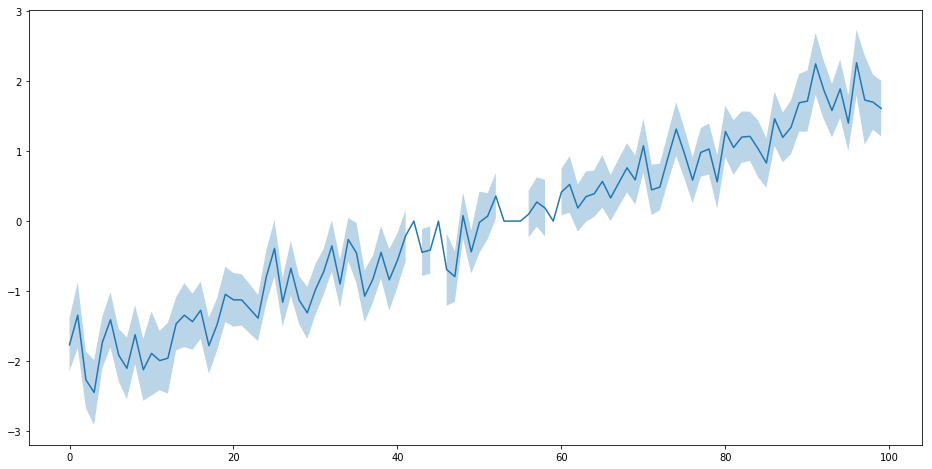

In [120]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,8))
plt.plot(results.params[1:101])
confidence_interval = results.conf_int(alpha=0.2)
plt.fill_between(range(M), confidence_interval[1:101,0], confidence_interval[1:101,1], alpha=0.3)
None

In [121]:
stats.kendalltau(results.params[1:101], range(100))

KendalltauResult(correlation=0.86616184700959253, pvalue=3.0808704313029502e-37)